<a href="https://colab.research.google.com/github/RubaEgbaria/Esch-Crowd-Monitoring/blob/master/Camera_only_pedestrian_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Camera-only Pedestrian Detection — YOLO vs Real KITTI Ground Truth


In [1]:
!pip install ultralytics -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 39.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.0/66.0 kB 5.3 MB/s eta 0:00:00


In [91]:
import glob
import os
import json
import matplotlib.pyplot as plt
from PIL import Image
from ultralytics import YOLO

data_root = "/content/"
# content includes: each image "NAME.jpg" should have a same-named "NAME.txt" next to it, with lines:
#   class_id x_center y_center width height

# Load model
model = YOLO('yolov8m.pt')

## 1) YOLO

In [92]:
def auto_annotate_frame(img_path, confidence_threshold=0.2):
    img = Image.open(img_path).convert("RGB")
    yolo_results_list = model(img, verbose=False)

    if not yolo_results_list:
        return []

    yolo_results = yolo_results_list[0]
    annotations = []
    for box_data in yolo_results.boxes:
        confidence = float(box_data.conf)
        if confidence < confidence_threshold:
            continue

        class_id = int(box_data.cls)
        label = yolo_results.names[class_id]
        if label != "person":
            continue

        x1, y1, x2, y2 = box_data.xyxy[0].tolist()
        cx = (x1 + x2) / 2
        cy = (y1 + y2) / 2

        annotations.append({
            "x": round(cx), "y": round(cy), "label": "person",
            "confidence": round(confidence, 2),
            "box": [round(x1), round(y1), round(x2), round(y2)],
        })
    return annotations

predictions = {}
image_files = sorted(glob.glob(os.path.join(data_root, "*.jpg")))
print(f"found {len(image_files)} images in {data_root}")

for img_path in image_files:
    fname = os.path.basename(img_path)
    predictions[fname] = auto_annotate_frame(img_path)
    print(f"{fname}: {len(predictions[fname])} person(s) detected")

with open("/content/predictions.json", "w") as f:
    json.dump(predictions, f, indent=2)

found 51 images in /content/
DMSA0442_GP104171_frame_0.jpg: 21 person(s) detected
DMSA0442_GP104171_frame_10500.jpg: 22 person(s) detected
DMSA0442_GP104171_frame_11250.jpg: 25 person(s) detected
DMSA0442_GP104171_frame_12000.jpg: 27 person(s) detected
DMSA0442_GP104171_frame_12750.jpg: 23 person(s) detected
DMSA0442_GP104171_frame_13500.jpg: 23 person(s) detected
DMSA0442_GP104171_frame_14250.jpg: 21 person(s) detected
DMSA0442_GP104171_frame_1500.jpg: 23 person(s) detected
DMSA0442_GP104171_frame_15000.jpg: 24 person(s) detected
DMSA0442_GP104171_frame_15750.jpg: 34 person(s) detected
DMSA0442_GP104171_frame_16500.jpg: 29 person(s) detected
DMSA0442_GP104171_frame_2250.jpg: 27 person(s) detected
DMSA0442_GP104171_frame_3000.jpg: 27 person(s) detected
DMSA0442_GP104171_frame_3750.jpg: 28 person(s) detected
DMSA0442_GP104171_frame_4500.jpg: 20 person(s) detected
DMSA0442_GP104171_frame_5250.jpg: 23 person(s) detected
DMSA0442_GP104171_frame_6000.jpg: 20 person(s) detected
DMSA0442_GP11

## 2) Ground truth from YOLO-format label files (top-view frames)


In [93]:
def build_ground_truth_from_yolo_labels(image_files, wanted_class_ids=(0,)):
    """
    Reads ground truth from YOLO-format .txt files that sit next to each image
    (same basename, e.g. DMSA0442_GP104171_frame_0.jpg -> DMSA0442_GP104171_frame_0.txt).
    Each line in the .txt file is: class_id x_center y_center width height
    with all four numbers normalized to [0, 1] relative to image width/height.
    class_id 0 is treated as "person" (change wanted_class_ids if your labels differ).
    """
    ground_truth = {}

    for img_path in image_files:
        fname = os.path.basename(img_path)
        label_path = os.path.splitext(img_path)[0] + ".txt"

        img = Image.open(img_path)
        img_w, img_h = img.size

        boxes = []
        if os.path.exists(label_path):
            with open(label_path, "r") as f:
                for line in f:
                    parts = line.strip().split()
                    if not parts:
                        continue

                    class_id = int(parts[0])
                    if class_id not in wanted_class_ids:
                        continue

                    xc, yc, bw, bh = map(float, parts[1:5])

                    # de-normalize YOLO center/width/height -> absolute pixel box
                    cx, cy = xc * img_w, yc * img_h
                    box_w, box_h = bw * img_w, bh * img_h
                    left = cx - box_w / 2
                    top = cy - box_h / 2
                    right = cx + box_w / 2
                    bottom = cy + box_h / 2

                    boxes.append({
                        "x": round(cx), "y": round(cy), "label": "person",
                        "box": [round(left), round(top), round(right), round(bottom)],
                    })
        else:
            print(f"warning: no label file found for {fname} (expected {os.path.basename(label_path)})")

        ground_truth[fname] = boxes

    return ground_truth

ground_truth = build_ground_truth_from_yolo_labels(image_files)

with open("/content/ground_truth.json", "w") as f:
    json.dump(ground_truth, f, indent=2)

print(f"loaded REAL ground truth for {len(ground_truth)} frames, "
      f"{sum(len(v) for v in ground_truth.values())} total labeled pedestrians")


loaded REAL ground truth for 51 frames, 2414 total labeled pedestrians


## 3) Ground Truth (Matching)

In [94]:
def match_detections_to_ground_truth(predictions, ground_truth, containment_threshold=0.3):
    """
    Ground truth boxes here are HEAD-only (small, near the top of each person),
    while YOLO's "person" boxes are FULL-BODY. Matching by center-to-center
    distance fails in this setup -- a head's center is nowhere near a body
    box's center, so almost everything ends up unmatched even for a visually
    correct detection.

    Instead, we match by containment: how much of the (small) GT head box is
    covered by the (large) predicted body box. If most of the head box falls
    inside a predicted box, that counts as a match -- this is robust to the
    head sitting near the top edge of the body box rather than its center.
    """
    unmatched_gt = list(range(len(ground_truth)))
    matched_pairs = []
    fp_indices = []

    def containment_ratio(gt_box, pred_box):
        gx0, gy0, gx1, gy1 = gt_box
        px0, py0, px1, py1 = pred_box
        ix0, iy0 = max(gx0, px0), max(gy0, py0)
        ix1, iy1 = min(gx1, px1), min(gy1, py1)
        iw, ih = max(0, ix1 - ix0), max(0, iy1 - iy0)
        inter_area = iw * ih
        gt_area = max(1e-6, (gx1 - gx0) * (gy1 - gy0))
        return inter_area / gt_area  # fraction of the GT head box covered by pred box

    for i, pred in enumerate(predictions):
        best_j, best_score = None, containment_threshold
        for j in unmatched_gt:
            gt = ground_truth[j]
            score = containment_ratio(gt["box"], pred["box"])
            if score > best_score:
                best_j, best_score = j, score
        if best_j is not None:
            matched_pairs.append((i, best_j, best_score))
            unmatched_gt.remove(best_j)
        else:
            fp_indices.append(i)

    return matched_pairs, fp_indices, unmatched_gt  # matched, false positives, false negatives

In [95]:
per_frame_results = []
total_tp, total_fp, total_fn = 0, 0, 0

for fname in sorted(ground_truth.keys()):
    preds = predictions.get(fname, [])
    gts = ground_truth.get(fname, [])
    matched, fp, fn = match_detections_to_ground_truth(preds, gts, containment_threshold=0.3)

    tp, fp_n, fn_n = len(matched), len(fp), len(fn)
    total_tp += tp; total_fp += fp_n; total_fn += fn_n

    precision = tp / (tp + fp_n) if (tp + fp_n) else 0
    recall = tp / (tp + fn_n) if (tp + fn_n) else 0
    per_frame_results.append({"frame": fname, "tp": tp, "fp": fp_n, "fn": fn_n,
                               "precision": round(precision, 2), "recall": round(recall, 2)})

print(f"{'frame':>20} {'TP':>4} {'FP':>4} {'FN':>4} {'prec':>6} {'recall':>7}")
for r in per_frame_results:
    print(f"{r['frame']:>20} {r['tp']:>4} {r['fp']:>4} {r['fn']:>4} {r['precision']:>6} {r['recall']:>7}")

overall_precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) else 0
overall_recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) else 0
overall_f1 = (2 * overall_precision * overall_recall / (overall_precision + overall_recall)
              if (overall_precision + overall_recall) else 0)

print(f"\n=== OVERALL (camera-only, {len(ground_truth)} frames) ===")
print(f"TP={total_tp}  FP={total_fp}  FN={total_fn}")
print(f"Precision={overall_precision:.2f}  Recall={overall_recall:.2f}  F1={overall_f1:.2f}")


               frame   TP   FP   FN   prec  recall
DMSA0442_GP104171_frame_0.jpg   15    6   28   0.71    0.35
DMSA0442_GP104171_frame_10500.jpg   20    2   32   0.91    0.38
DMSA0442_GP104171_frame_11250.jpg   24    1   39   0.96    0.38
DMSA0442_GP104171_frame_12000.jpg   26    1   24   0.96    0.52
DMSA0442_GP104171_frame_12750.jpg   19    4   26   0.83    0.42
DMSA0442_GP104171_frame_13500.jpg   23    0   25    1.0    0.48
DMSA0442_GP104171_frame_14250.jpg   17    4   31   0.81    0.35
DMSA0442_GP104171_frame_1500.jpg   19    4   27   0.83    0.41
DMSA0442_GP104171_frame_15000.jpg   20    4   38   0.83    0.34
DMSA0442_GP104171_frame_15750.jpg   27    7   36   0.79    0.43
DMSA0442_GP104171_frame_16500.jpg   27    2   68   0.93    0.28
DMSA0442_GP104171_frame_2250.jpg   23    4   34   0.85     0.4
DMSA0442_GP104171_frame_3000.jpg   23    4   28   0.85    0.45
DMSA0442_GP104171_frame_3750.jpg   23    5   27   0.82    0.46
DMSA0442_GP104171_frame_4500.jpg   16    4   22    0.8    0.4

## 4) Confusion Matrix

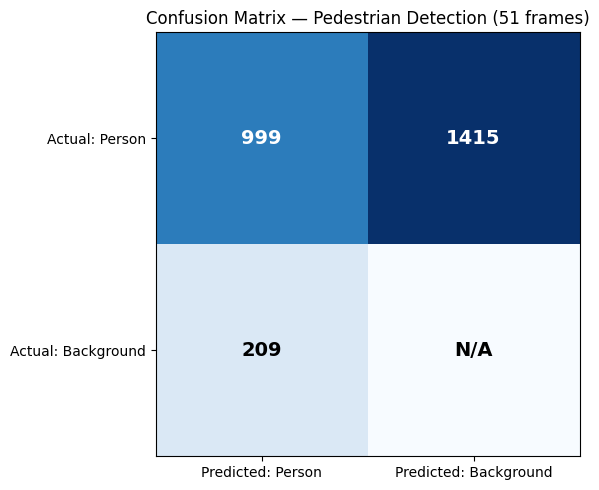

Accuracy (TP / (TP+FP+FN)) = 38.09%
Precision = 82.70%
Recall    = 41.38%
F1 Score  = 55.16%


In [96]:
import numpy as np

cm = np.array([[total_tp, total_fn],
               [total_fp, 0]])

labels = ["Detected", "Missed (FN)"]
row_labels = ["Actual: Person", "Actual: Background"]
col_labels = ["Predicted: Person", "Predicted: Background"]

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")

ax.set_xticks([0, 1]); ax.set_xticklabels(col_labels)
ax.set_yticks([0, 1]); ax.set_yticklabels(row_labels)

for i in range(2):
    for j in range(2):
        val = cm[i, j]
        txt = str(val) if not (i == 1 and j == 1) else "N/A"
        ax.text(j, i, txt, ha="center", va="center",
                color="white" if val > cm.max() / 2 else "black", fontsize=14, weight="bold")

ax.set_title(f"Confusion Matrix — Pedestrian Detection ({len(ground_truth)} frames)")
plt.tight_layout()
plt.show()

print(f"Accuracy (TP / (TP+FP+FN)) = {total_tp / (total_tp + total_fp + total_fn):.2%}")
print(f"Precision = {overall_precision:.2%}")
print(f"Recall    = {overall_recall:.2%}")
print(f"F1 Score  = {overall_f1:.2%}")


## 5) More visulaizations

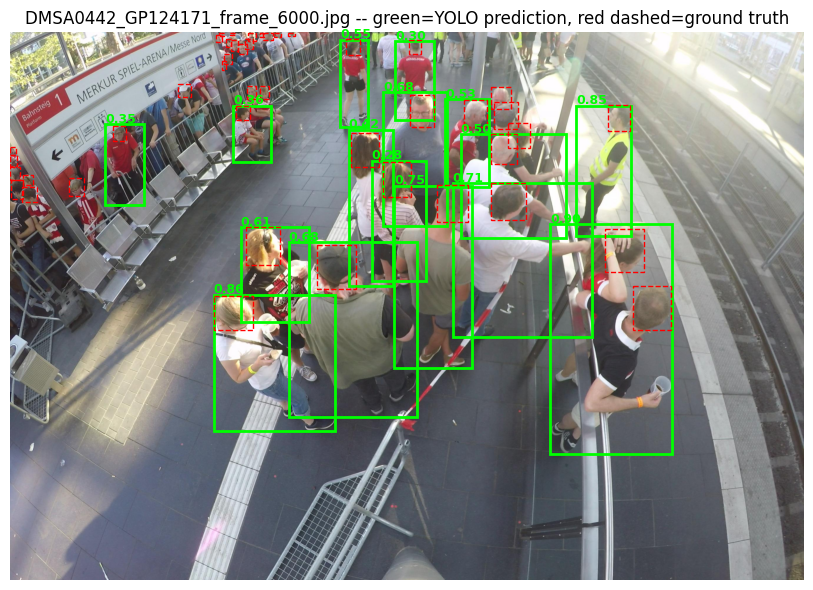

In [97]:
from IPython.display import clear_output
import time
from matplotlib.patches import Rectangle

def play_detection_video(image_files, predictions, ground_truth=None, delay_seconds=1.0):
    ordered_files = sorted(image_files, key=lambda p: os.path.basename(p))

    for img_path in ordered_files:
        fname = os.path.basename(img_path)
        preds = predictions.get(fname, [])
        gts = ground_truth.get(fname, []) if ground_truth else []

        clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(14, 6))
        ax.imshow(Image.open(img_path))

        for p in preds:
            x0, y0, x1, y1 = p["box"]
            ax.add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, edgecolor="lime", linewidth=2))
            ax.text(x0, y0 - 5, f"{p['confidence']:.2f}", color="lime", fontsize=9, weight="bold")

        for g in gts:
            x0, y0, x1, y1 = g["box"]
            ax.add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, edgecolor="red", linewidth=1, linestyle="--"))

        ax.set_title(f"{fname} -- green=YOLO prediction, red dashed=ground truth")
        ax.axis("off")
        plt.tight_layout()
        plt.show()
        time.sleep(delay_seconds)

play_detection_video(image_files, predictions, ground_truth, delay_seconds=1.0)


In [98]:
import cv2
import numpy as np
from PIL import ImageDraw, ImageFont

def export_detection_video(image_files, predictions, output_path="detections.mp4", fps=2):
    ordered_files = sorted(image_files, key=lambda p: os.path.basename(p))

    # Get frame size from the first image
    first_img = Image.open(ordered_files[0]).convert("RGB")
    w, h = first_img.size

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(output_path, fourcc, fps, (w, h))

    for img_path in ordered_files:
        fname = os.path.basename(img_path)
        preds = predictions.get(fname, [])

        img = Image.open(img_path).convert("RGB")
        draw = ImageDraw.Draw(img)

        for p in preds:
            x0, y0, x1, y1 = p["box"]
            draw.rectangle([x0, y0, x1, y1], outline="lime", width=2)
            draw.text((x0, max(0, y0 - 12)), f"{p['confidence']:.2f}", fill="lime")

        # PIL is RGB, OpenCV wants BGR
        frame = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR)
        writer.write(frame)

    writer.release()
    print(f"Saved video to {output_path}")

export_detection_video(image_files, predictions, output_path="detections.mp4", fps=2)

Saved video to detections.mp4


In [99]:
from google.colab import files
files.download("detections.mp4")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>